# Umesh Dhakal
# MSCS634
# Lab 6
# Association Rule Mining with Apriori and FP-Growth

In [1]:
# Importing libries
import io
import time
import zipfile
import warnings
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Loading dataset from UCI
url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url, timeout=60)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    excel_file = [name for name in zf.namelist() if name.endswith(".xlsx")][0]
    with zf.open(excel_file) as f:
        df_raw = pd.read_excel(f)

print("Dataset loaded successfully")
print("Shape of dataset:", df_raw.shape)
df_raw.head()

Dataset loaded successfully
Shape of dataset: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Few informations of datasets
print(df_raw.info())
print("\nMissing values:")
print(df_raw.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB
None

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# Data clean
df = df_raw.copy()

# Remove canceled invoices
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")]

# Remove missing and invalid rows
df = df[df["Description"].notna()]
df["Description"] = df["Description"].astype(str).str.strip()
df = df[df["Description"].str.lower() != "nan"]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df = df[df["Country"] == "France"].copy()

print("Cleaned dataset shape:", df.shape)
print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique items:", df["Description"].nunique())
df.head()

Cleaned dataset shape: (8407, 8)
Unique invoices: 392
Unique items: 1563


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France


In [5]:
# Few rows of cleaned data
display(df.head())

# Checking missing values after cleaning
print(df.isnull().sum())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France


InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID     66
Country         0
dtype: int64


In [6]:
# Top frequent items
top_items = df["Description"].value_counts().head(15).reset_index()
top_items.columns = ["Item", "Count"]
top_items

,Item,Count
0,POSTAGE,300
1,RABBIT NIGHT LIGHT,74
2,RED TOADSTOOL LED NIGHT LIGHT,71
3,PLASTERS IN TIN WOODLAND ANIMALS,68
4,PLASTERS IN TIN CIRCUS PARADE,66
5,ROUND SNACK BOXES SET OF4 WOODLAND,62
6,LUNCH BAG RED RETROSPOT,60
7,LUNCH BOX WITH CUTLERY RETROSPOT,56
8,RED RETROSPOT MINI CASES,54
9,PLASTERS IN TIN SPACEBOY,54


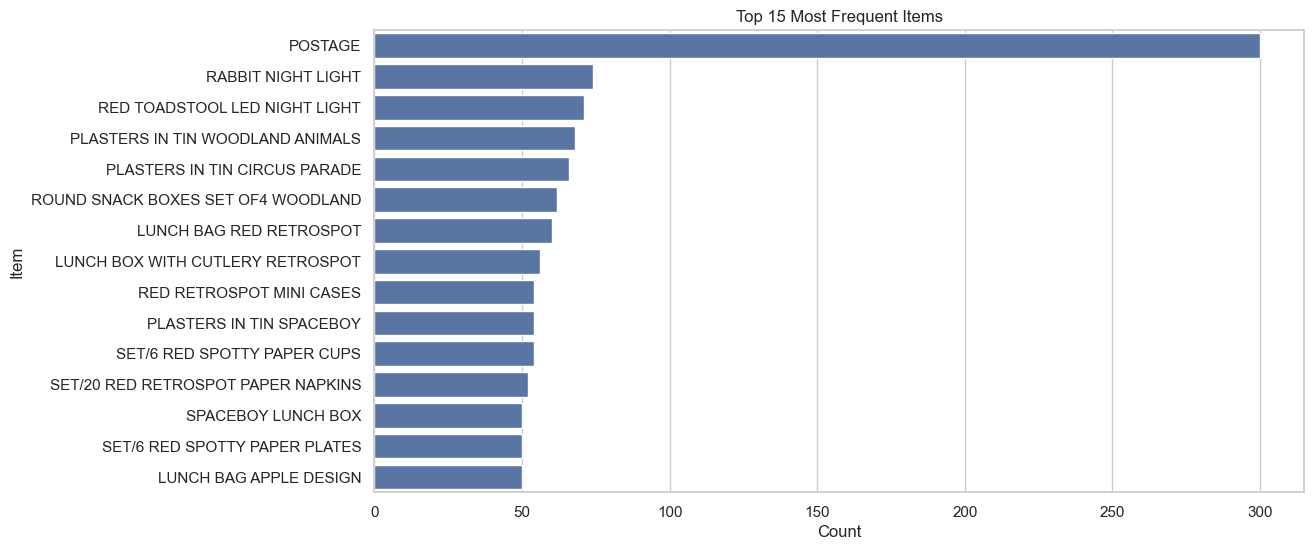

In [7]:
# Top frequent items Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=top_items, x="Count", y="Item")
plt.title("Top 15 Most Frequent Items")
plt.xlabel("Count")
plt.ylabel("Item")
plt.show()

In [8]:
# Creating basket data
basket = (
    df.groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

# Converting quantity to 0 and 1
basket = (basket > 0).astype(int)

print("Basket shape:", basket.shape)
basket.head()

Basket shape: (392, 1563)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,15CM CHRISTMAS GLASS BALL 20 LIGHTS,16 PIECE CUTLERY SET PANTRY DESIGN,18PC WOODEN CUTLERY SET DISPOSABLE,20 DOLLY PEGS RETROSPOT,200 RED + WHITE BENDY STRAWS,3 HOOK HANGER MAGIC GARDEN,3 PIECE SPACEBOY COOKIE CUTTER SET,3 RAFFIA RIBBONS 50'S CHRISTMAS,3 STRIPEY MICE FELTCRAFT,3 TIER CAKE TIN RED AND CREAM,3 TRADITIONAl BISCUIT CUTTERS SET,36 DOILIES DOLLY GIRL,36 DOILIES VINTAGE CHRISTMAS,36 FOIL HEART CAKE CASES,36 FOIL STAR CAKE CASES,...,WRAP CAROUSEL,WRAP CHRISTMAS VILLAGE,WRAP CIRCUS PARADE,WRAP DOILEY DESIGN,WRAP DOLLY GIRL,WRAP ENGLISH ROSE,WRAP GINGHAM ROSE,WRAP GREEN PEARS,WRAP I LOVE LONDON,WRAP PAISLEY PARK,WRAP PINK FAIRY CAKES,WRAP POPPIES DESIGN,WRAP RED APPLES,WRAP RED VINTAGE DOILY,WRAP SUKI AND FRIENDS,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
536370,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
536852,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
536974,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
537065,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
537463,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


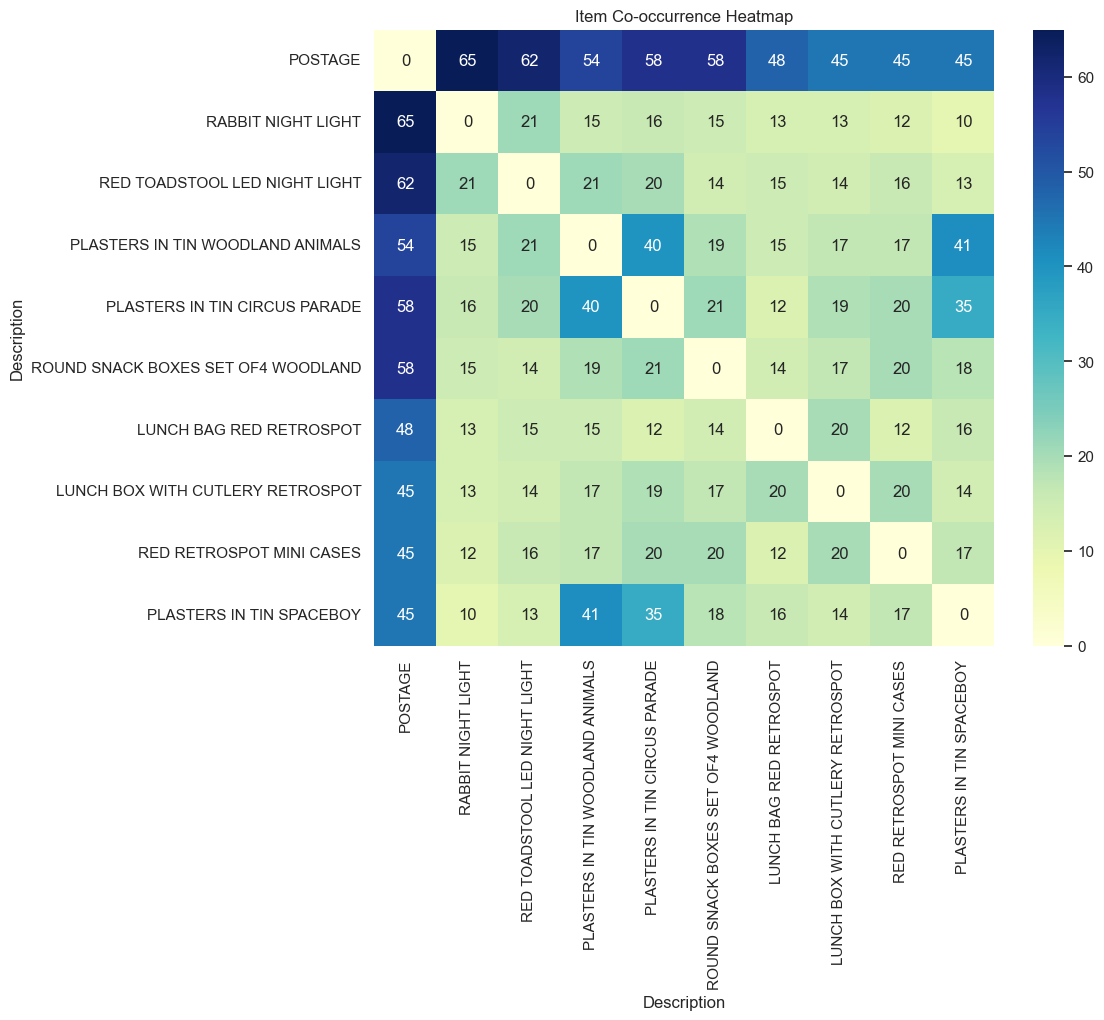

In [9]:
# Heatmap of item co-occurrence
top_10_items = top_items["Item"].head(10).tolist()

co_occurrence = basket[top_10_items].T.dot(basket[top_10_items])

# Removing diagonal values
co_occurrence = co_occurrence.copy()
for i in range(len(co_occurrence)):
    co_occurrence.iat[i, i] = 0

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Item Co-occurrence Heatmap")
plt.show()

In [10]:
# Frequent Itemset Mining using Apriori
min_support = 0.03
min_confidence = 0.40

start_apr = time.perf_counter()

apriori_itemsets = apriori(
    basket,
    min_support=min_support,
    use_colnames=True,
    max_len=3
)

apriori_time = time.perf_counter() - start_apr

apriori_itemsets["Length"] = apriori_itemsets["itemsets"].apply(len)
apriori_itemsets = apriori_itemsets.sort_values(["support", "Length"], ascending=[False, False])

print("Apriori runtime:", round(apriori_time, 4), "seconds")
print("Number of frequent itemsets:", len(apriori_itemsets))
apriori_itemsets.head(20)

Apriori runtime: 0.4547 seconds
Number of frequent itemsets: 731


,support,itemsets,Length
105,0.765306,frozenset({POSTAGE}),1
106,0.188776,frozenset({RABBIT NIGHT LIGHT}),1
120,0.181122,frozenset({RED TOADSTOOL LED NIGHT LIGHT}),1
100,0.170918,frozenset({PLASTERS IN TIN WOODLAND ANIMALS}),1
95,0.168367,frozenset({PLASTERS IN TIN CIRCUS PARADE}),1
447,0.165816,"frozenset({RABBIT NIGHT LIGHT, POSTAGE})",2
458,0.158163,"frozenset({POSTAGE, RED TOADSTOOL LED NIGHT LIGHT})",2
129,0.158163,frozenset({ROUND SNACK BOXES SET OF4 WOODLAND}),1
73,0.153061,frozenset({LUNCH BAG RED RETROSPOT}),1
400,0.147959,"frozenset({POSTAGE, PLASTERS IN TIN CIRCUS PARADE})",2


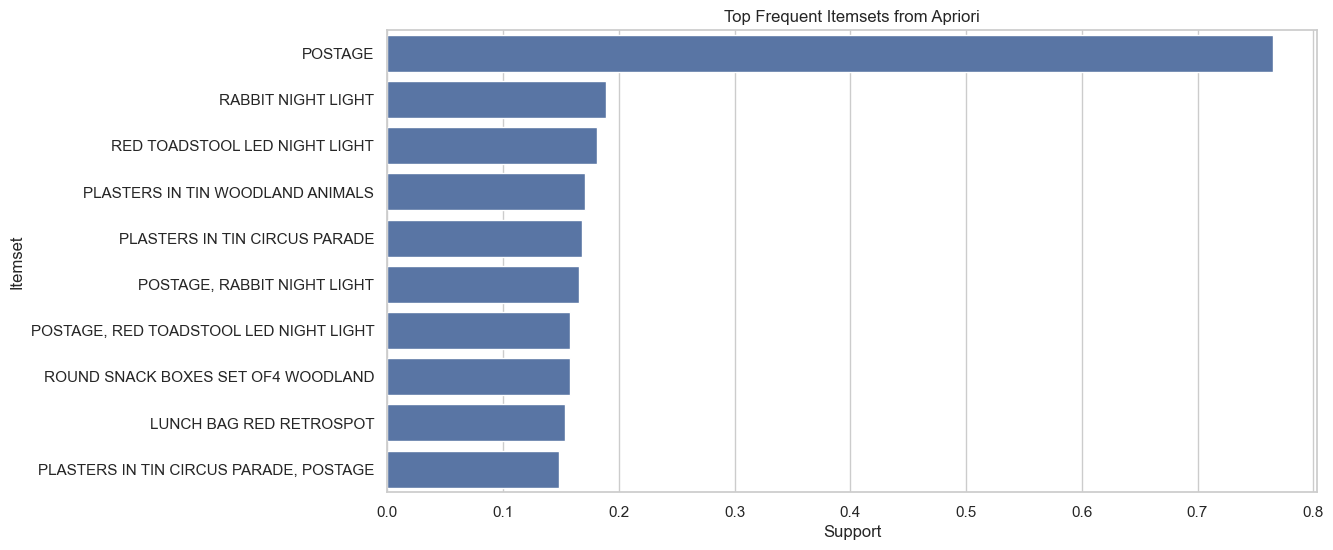

In [11]:
def itemset_to_text(x):
    return ", ".join(sorted(list(x)))

apriori_plot = apriori_itemsets.copy()
apriori_plot["Itemset"] = apriori_plot["itemsets"].apply(itemset_to_text)

# Using top frequent itemsets for plot
top_apriori = apriori_plot.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_apriori, x="support", y="Itemset")
plt.title("Top Frequent Itemsets from Apriori")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.show()

### Apriori Analysis
- I used the Apriori algorithm to find frequent itemsets.
- I selected a support threshold of 0.03 so I could get meaningful patterns without too many unnecessary itemsets.
- The results show which combinations of products appeared often in the transactions.

In [12]:
# Frequent Itemset Mining using FP-Growth
start_fp = time.perf_counter()

fp_itemsets = fpgrowth(
    basket,
    min_support=min_support,
    use_colnames=True,
    max_len=3
)

fp_time = time.perf_counter() - start_fp

fp_itemsets["Length"] = fp_itemsets["itemsets"].apply(len)
fp_itemsets = fp_itemsets.sort_values(["support", "Length"], ascending=[False, False])

print("FP-Growth runtime:", round(fp_time, 4), "seconds")
print("Number of frequent itemsets:", len(fp_itemsets))
fp_itemsets.head(20)

FP-Growth runtime: 0.1114 seconds
Number of frequent itemsets: 731


,support,itemsets,Length
0,0.765306,frozenset({POSTAGE}),1
147,0.188776,frozenset({RABBIT NIGHT LIGHT}),1
1,0.181122,frozenset({RED TOADSTOOL LED NIGHT LIGHT}),1
25,0.170918,frozenset({PLASTERS IN TIN WOODLAND ANIMALS}),1
72,0.168367,frozenset({PLASTERS IN TIN CIRCUS PARADE}),1
701,0.165816,"frozenset({RABBIT NIGHT LIGHT, POSTAGE})",2
171,0.158163,"frozenset({POSTAGE, RED TOADSTOOL LED NIGHT LIGHT})",2
2,0.158163,frozenset({ROUND SNACK BOXES SET OF4 WOODLAND}),1
14,0.153061,frozenset({LUNCH BAG RED RETROSPOT}),1
174,0.147959,"frozenset({POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND})",2


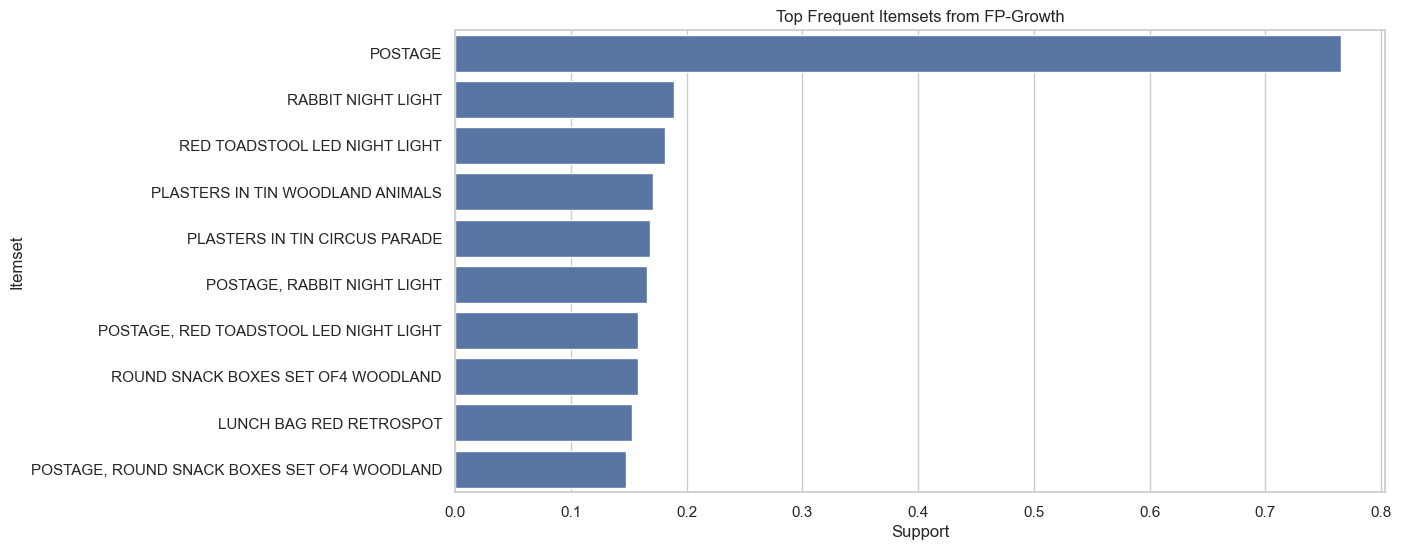

In [13]:
# Visualization of FP-Growth itemsets
fp_plot = fp_itemsets.copy()
fp_plot["Itemset"] = fp_plot["itemsets"].apply(itemset_to_text)

top_fp = fp_plot.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_fp, x="support", y="Itemset")
plt.title("Top Frequent Itemsets from FP-Growth")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.show()

### FP-Growth Analysis
- In this step, I used the FP-Growth algorithm with the same support threshold as Apriori.
- This makes the comparison fair.
- FP-Growth also found frequent itemsets, and later I compared its speed and output with Apriori.

In [14]:
# Generating Association rules from Apriori
apriori_rules = association_rules(
    apriori_itemsets,
    metric="confidence",
    min_threshold=min_confidence
)

apriori_rules = apriori_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

print("Number of Apriori rules:", len(apriori_rules))
apriori_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

Number of Apriori rules: 842


,antecedents,consequents,support,confidence,lift
0,frozenset({SPACEBOY CHILDRENS CUP}),frozenset({DOLLY GIRL CHILDRENS CUP}),0.030612,0.923077,22.615385
1,frozenset({DOLLY GIRL CHILDRENS CUP}),frozenset({SPACEBOY CHILDRENS CUP}),0.030612,0.750000,22.615385
2,"frozenset({SPACEBOY CHILDRENS BOWL, DOLLY GIRL CHILDRENS CUP})",frozenset({DOLLY GIRL CHILDRENS BOWL}),0.033163,1.000000,21.777778
3,frozenset({DOLLY GIRL CHILDRENS BOWL}),"frozenset({SPACEBOY CHILDRENS BOWL, DOLLY GIRL CHILDRENS CUP})",0.033163,0.722222,21.777778
4,frozenset({WOODLAND MINI BACKPACK}),frozenset({DOLLY GIRL MINI BACKPACK}),0.035714,0.875000,21.437500
5,frozenset({DOLLY GIRL MINI BACKPACK}),frozenset({WOODLAND MINI BACKPACK}),0.035714,0.875000,21.437500
6,frozenset({CHILDS BREAKFAST SET DOLLY GIRL}),frozenset({CHILDS BREAKFAST SET SPACEBOY}),0.030612,0.923077,21.285068
7,frozenset({CHILDS BREAKFAST SET SPACEBOY}),frozenset({CHILDS BREAKFAST SET DOLLY GIRL}),0.030612,0.705882,21.285068
8,"frozenset({WOODLAND MINI BACKPACK, POSTAGE})",frozenset({DOLLY GIRL MINI BACKPACK}),0.030612,0.857143,21.000000
9,"frozenset({POSTAGE, DOLLY GIRL MINI BACKPACK})",frozenset({WOODLAND MINI BACKPACK}),0.030612,0.857143,21.000000


In [16]:
# Generating association rules from FP-Growth
fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=min_confidence
)

fp_rules = fp_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

print("Number of FP-Growth rules:", len(fp_rules))
fp_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

Number of FP-Growth rules: 842


,antecedents,consequents,support,confidence,lift
0,frozenset({SPACEBOY CHILDRENS CUP}),frozenset({DOLLY GIRL CHILDRENS CUP}),0.030612,0.923077,22.615385
1,frozenset({DOLLY GIRL CHILDRENS CUP}),frozenset({SPACEBOY CHILDRENS CUP}),0.030612,0.750000,22.615385
2,"frozenset({SPACEBOY CHILDRENS BOWL, DOLLY GIRL CHILDRENS CUP})",frozenset({DOLLY GIRL CHILDRENS BOWL}),0.033163,1.000000,21.777778
3,frozenset({DOLLY GIRL CHILDRENS BOWL}),"frozenset({SPACEBOY CHILDRENS BOWL, DOLLY GIRL CHILDRENS CUP})",0.033163,0.722222,21.777778
4,frozenset({WOODLAND MINI BACKPACK}),frozenset({DOLLY GIRL MINI BACKPACK}),0.035714,0.875000,21.437500
5,frozenset({DOLLY GIRL MINI BACKPACK}),frozenset({WOODLAND MINI BACKPACK}),0.035714,0.875000,21.437500
6,frozenset({CHILDS BREAKFAST SET DOLLY GIRL}),frozenset({CHILDS BREAKFAST SET SPACEBOY}),0.030612,0.923077,21.285068
7,frozenset({CHILDS BREAKFAST SET SPACEBOY}),frozenset({CHILDS BREAKFAST SET DOLLY GIRL}),0.030612,0.705882,21.285068
8,"frozenset({WOODLAND MINI BACKPACK, POSTAGE})",frozenset({DOLLY GIRL MINI BACKPACK}),0.030612,0.857143,21.000000
9,"frozenset({POSTAGE, DOLLY GIRL MINI BACKPACK})",frozenset({WOODLAND MINI BACKPACK}),0.030612,0.857143,21.000000


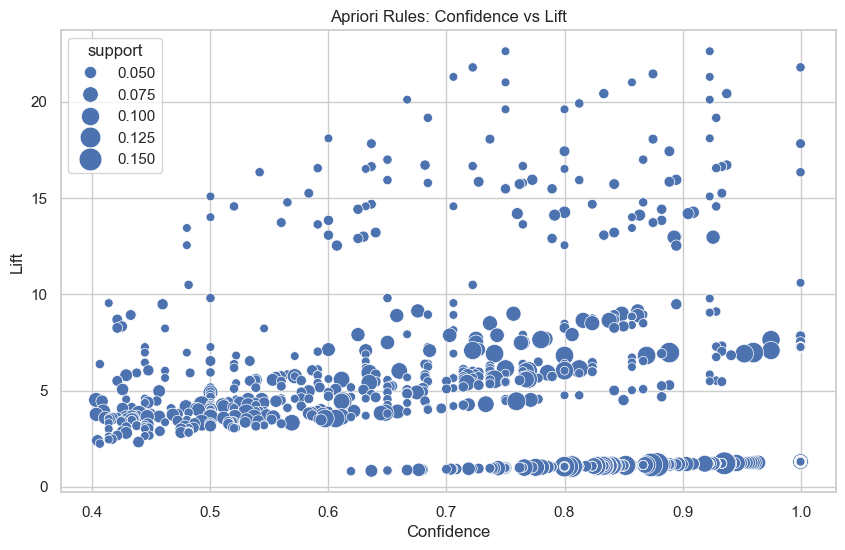

In [17]:
# Scatter plot for Apriori rules
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=apriori_rules,
    x="confidence",
    y="lift",
    size="support",
    sizes=(40, 300)
)
plt.title("Apriori Rules: Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.show()

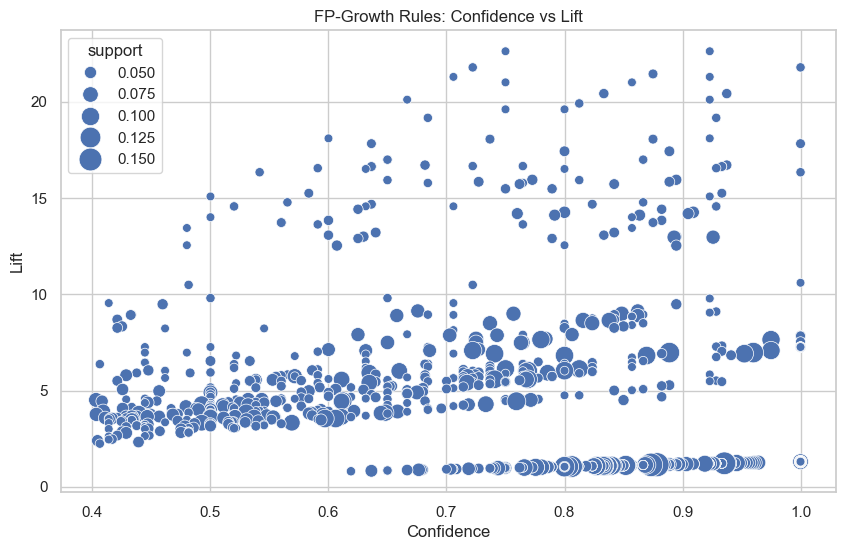

In [18]:
# Scatter plot for FP-Growth rules
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=fp_rules,
    x="confidence",
    y="lift",
    size="support",
    sizes=(40, 300)
)
plt.title("FP-Growth Rules: Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.show()

In [19]:
# Top rules
def show_rules(rules_df, label, top_n=5):
    print("\nTop rules from", label)

    top_rules = rules_df[["antecedents", "consequents", "support", "confidence", "lift"]].head(top_n)

    for i, row in top_rules.iterrows():
        left = ", ".join(sorted(list(row["antecedents"])))
        right = ", ".join(sorted(list(row["consequents"])))

        print(
            f"{i+1}. If a customer buys [{left}], they also tend to buy [{right}]. "
            f"Support = {row['support']:.4f}, Confidence = {row['confidence']:.4f}, Lift = {row['lift']:.4f}"
        )

show_rules(apriori_rules, "Apriori")
show_rules(fp_rules, "FP-Growth")


Top rules from Apriori
1. If a customer buys [SPACEBOY CHILDRENS CUP], they also tend to buy [DOLLY GIRL CHILDRENS CUP]. Support = 0.0306, Confidence = 0.9231, Lift = 22.6154
2. If a customer buys [DOLLY GIRL CHILDRENS CUP], they also tend to buy [SPACEBOY CHILDRENS CUP]. Support = 0.0306, Confidence = 0.7500, Lift = 22.6154
3. If a customer buys [DOLLY GIRL CHILDRENS CUP, SPACEBOY CHILDRENS BOWL], they also tend to buy [DOLLY GIRL CHILDRENS BOWL]. Support = 0.0332, Confidence = 1.0000, Lift = 21.7778
4. If a customer buys [DOLLY GIRL CHILDRENS BOWL], they also tend to buy [DOLLY GIRL CHILDRENS CUP, SPACEBOY CHILDRENS BOWL]. Support = 0.0332, Confidence = 0.7222, Lift = 21.7778
5. If a customer buys [WOODLAND MINI BACKPACK], they also tend to buy [DOLLY GIRL MINI BACKPACK]. Support = 0.0357, Confidence = 0.8750, Lift = 21.4375

Top rules from FP-Growth
1. If a customer buys [SPACEBOY CHILDRENS CUP], they also tend to buy [DOLLY GIRL CHILDRENS CUP]. Support = 0.0306, Confidence = 0.923

### Association Rule Analysis
- I generated association rules using a confidence threshold of 0.40.
- I included support, confidence, and lift to understand the strength of each rule.
- Rules with higher confidence and higher lift show stronger and more meaningful product relationships.

In [20]:
# Comparison of Apriori and FP-Growth
comparison_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Runtime": [apriori_time, fp_time],
    "Frequent Itemsets": [len(apriori_itemsets), len(fp_itemsets)],
    "Association Rules": [len(apriori_rules), len(fp_rules)]
})

comparison_df

,Algorithm,Runtime,Frequent Itemsets,Association Rules
0,Apriori,0.454653,731,842
1,FP-Growth,0.111407,731,842


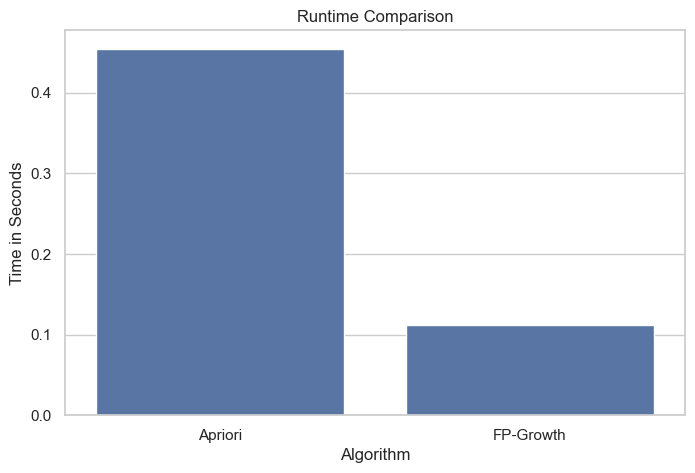

In [21]:
# Runtime comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Algorithm", y="Runtime")
plt.title("Runtime Comparison")
plt.ylabel("Time in Seconds")
plt.show()

## Comparative Analysis

- Apriori and FP-Growth gave the same results. Both algorithms found 731 frequent itemsets and generated 842 association rules.

- The main difference was runtime, Apriori took 0.4547 seconds whereas FP-Growth took 0.1114 seconds. This shows that FP-Growth was faster than Apriori.

- FP-Growth was faster because it uses a tree-based method and avoids generating too many candidate itemsets whereas Apriori takes more time because it checks many possible item combinations again and again.

- Overall, both algorithms gave the same mining results, but FP-Growth was faster and more efficient for this dataset.

- One challenge I faced in this lab was working with a large dataset that had many different items, which made the analysis more difficult. I also had to clean the data carefully by removing canceled invoices, missing values, and invalid rows before applying the mining algorithms.